In [1]:
import pandas as pd
import numpy as np
import sys
import os
import joblib

# import some libraries for training
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import TransformedTargetRegressor
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import matplotlib.pyplot as plt

from helper_modules import phase2_preprocess_data

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

# disable some warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="hyperopt")


In [2]:
df = pd.read_csv(os.path.join('datasets', 'flextrack_phase1_train.csv'))
print(df.shape)
display(df.head())

(105120, 7)


,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0


In [3]:
# Try extracting data that has Demand_Response_Flag = 0 and Demand_Response_Capacity_kW != 0.0
df1 = df[
    (df['Demand_Response_Flag']==0) &
    (df['Demand_Response_Capacity_kW'] != 0.0)
].copy(deep=True)
print (df1.shape[0])

df1 = df[
    df['Demand_Response_Flag']==0
].copy(deep=True)
df2 = df1[
    df1['Demand_Response_Capacity_kW'] != 0.0
].copy(deep=True)
print (df2.shape[0])
# We observe that if Demand_Response_Flag = 0, then Demand_Response_Capacity_kW is always 0.0

0
0


,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW,Hour,Day,DOW,Month,Weekday,Minute,Hour_sin,Hour_cos,DOW_sin,DOW_cos,HDD18,CDD22,TempC2,rad_sqrt,rad_log1p,is_daylight,TempC_x_daylight,CDD22_x_daylight,TempC_x_hour_sin,TempC_x_hour_cos,Is_Weekend,Is_Summer,Is_Winter,Is_Afternoon,Is_Evening
0,22.20,0.0,4.8,0,0.0,0,1,1,1,1,0,0.000000,1.000000,0.781831,0.62349,0.0,0.20,492.8400,0.0,0.0,0,0.0,0.0,0.000000,22.200000,0,0,1,0,0
1,22.27,0.0,4.8,0,0.0,0,1,1,1,1,15,0.000000,1.000000,0.781831,0.62349,0.0,0.27,495.9529,0.0,0.0,0,0.0,0.0,0.000000,22.270000,0,0,1,0,0
2,22.35,0.0,4.8,0,0.0,0,1,1,1,1,30,0.000000,1.000000,0.781831,0.62349,0.0,0.35,499.5225,0.0,0.0,0,0.0,0.0,0.000000,22.350000,0,0,1,0,0
3,22.42,0.0,4.8,0,0.0,0,1,1,1,1,45,0.000000,1.000000,0.781831,0.62349,0.0,0.42,502.6564,0.0,0.0,0,0.0,0.0,0.000000,22.420000,0,0,1,0,0
4,22.50,0.0,4.8,0,0.0,1,1,1,1,1,0,0.258819,0.965926,0.781831,0.62349,0.0,0.50,506.2500,0.0,0.0,0,0.0,0.0,5.823429,21.733331,0,0,1,0,0


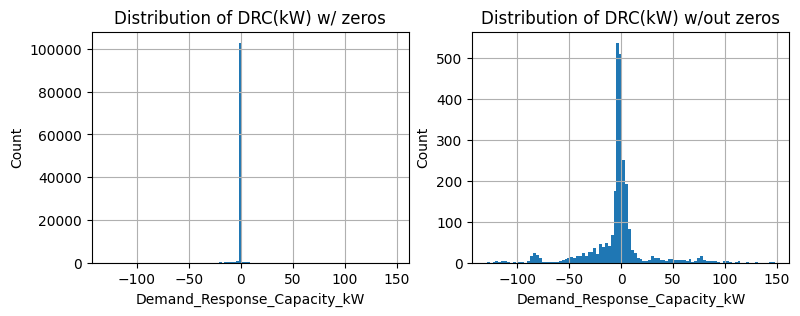

In [4]:
# perform some preprocessing
df = phase2_preprocess_data(df)
display(df.head())

# Visualize the distribution of Demand_Response_Capacity_kW
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(9, 3))
df['Demand_Response_Capacity_kW'].hist(bins=100, ax=ax1)
ax1.set_title('Distribution of DRC(kW) w/ zeros')
ax1.set_xlabel('Demand_Response_Capacity_kW')
ax1.set_ylabel('Count')

df[
    df['Demand_Response_Capacity_kW'] != 0.0
]['Demand_Response_Capacity_kW'].hist(bins=100, ax=ax2)
ax2.set_title('Distribution of DRC(kW) w/out zeros')
ax2.set_xlabel('Demand_Response_Capacity_kW')
ax2.set_ylabel('Count')
plt.show()

In [5]:
# suspects.remove('Building_Power_kW')
df = df.drop_duplicates()


# So our modeling for phase 2 will be:
# 1) if Demand_Response_Flag == 0, automatically predict Demand_Response_Capacity_kW = 0
# 2) if Demand_Response_Flag == 1 or -1, then we will train a xgb-regressor model to predict Demand_Response_Capacity_kW

best_hyperparams = {
    'clf_colsample_bytree': np.float64(0.8665082198431755),
    'clf_gamma': np.float64(0.013100764586808401),
    'clf_learning_rate': np.float64(0.19219434533660285),
    'clf_max_depth': np.float64(4.0),
    'clf_n_estimators': np.float64(350.0),
    'clf_reg_alpha': np.float64(0.03154689614002081),
    'clf_reg_lambda': np.float64(0.14144620241279848),
    'clf_subsample': np.float64(0.7426063316533168),
    'reg_gamma': np.float64(1.783173939388729),
    'reg_learning_rate': np.float64(0.18333065602749388),
    'reg_max_depth': np.float64(5.0),
    'reg_n_estimators': np.float64(800.0),
    'reg_reg_alpha': np.float64(3.0913670976103353),
    'reg_reg_lambda': np.float64(4.039216554382852)
}

# Begin modeling.

# First, We need to drop observations where Demand_Response_Flag == 0
df = df[df['Demand_Response_Flag'] != 0].copy(deep=True)
X = df.drop(columns=['Demand_Response_Capacity_kW'])
X = X.values
y = df['Demand_Response_Capacity_kW'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=500/X.shape[0], random_state=42, stratify=(y != 0).astype(int))

# create labels for those guys that have non-zero Demand_Response_Capacity_kW
# is_nz : = 0 if value of Demand_Response_Capacity_kW  = 0
#       : = 1 if value of Demand_Response_Capacity_kW != 0
is_nz = (y_train != 0).astype(int)

# is_nz = (abs(y_train) > 0.1).astype(int)

# 1) Zero vs non-zero:
#    Train XGBoost classifier to identify which observations have zero value for 'Demand_Response_Capacity_kW'
#    So we have 2 classes: 0 (zero) and 1 (non-zero) for 'Demand_Response_Capacity_kW'
clf_nz = xgb.XGBClassifier(
    n_estimators=int(best_hyperparams['clf_n_estimators']), 
    max_depth=int(best_hyperparams['clf_max_depth']), 
    learning_rate=best_hyperparams['clf_learning_rate'],
    subsample=best_hyperparams['clf_subsample'], 
    colsample_bytree=best_hyperparams['clf_colsample_bytree'],
    gamma=best_hyperparams['clf_gamma'],
    reg_lambda=best_hyperparams['clf_reg_lambda'],
    reg_alpha=best_hyperparams['clf_reg_alpha'],
    eval_metric="logloss",
    # handle class imbalance (zeros >> non-zeros)
    scale_pos_weight=(is_nz==0).sum() / max((is_nz==1).sum(), 1),
    random_state=42,
).fit(X_train, is_nz)

# 2) Train XGBoost regressor:
#    only on non-zero observations i.e., we will regress 'Demand_Response_Capacity_kW' on non-zero values
mask = is_nz == 1
reg_nz = xgb.XGBRegressor(
    objective='reg:squarederror',
    # objective='reg:pseudohubererror',
    n_estimators=int(best_hyperparams['reg_n_estimators']),
    max_depth=int(best_hyperparams['reg_max_depth']),
    learning_rate=best_hyperparams['reg_learning_rate'],
    gamma=best_hyperparams['reg_gamma'],
    reg_lambda=best_hyperparams['reg_reg_lambda'],
    reg_alpha=best_hyperparams['reg_reg_alpha'],
    random_state=42
)

# reg_nz = TransformedTargetRegressor(
#     regressor=reg, func=np.arcsinh, inverse_func=np.sinh
# )
reg_nz.fit(X_train[mask], y_train[mask])

# Inference: Predict on test set
p_nz = clf_nz.predict_proba(X_test)[:, 1]
mu_nz = reg_nz.predict(X_test)
y_pred = p_nz * mu_nz

In [6]:
def objective(params):
    # Classifier params
    clf_params = {
        'n_estimators': int(params['clf_n_estimators']),
        'max_depth': int(params['clf_max_depth']),
        'learning_rate': params['clf_learning_rate'],
        'subsample': params['clf_subsample'],
        'colsample_bytree': params['clf_colsample_bytree'],
        'gamma': params['clf_gamma'],
        'reg_lambda': params['clf_reg_lambda'],
        'reg_alpha': params['clf_reg_alpha'],
        'eval_metric': "logloss",
        'scale_pos_weight': (is_nz==0).sum() / max((is_nz==1).sum(), 1),
        'random_state': 42,
        'use_label_encoder': False
    }
    clf = xgb.XGBClassifier(**clf_params)
    clf.fit(X_train, is_nz)

    # Regressor params
    mask = is_nz == 1
    reg_params = {
        'objective': 'reg:squarederror',
        'n_estimators': int(params['reg_n_estimators']),
        'max_depth': int(params['reg_max_depth']),
        'learning_rate': params['reg_learning_rate'],
        'gamma': params['reg_gamma'],
        'reg_lambda': params['reg_reg_lambda'],
        'reg_alpha': params['reg_reg_alpha'],
        'random_state': 42
    }
    reg = xgb.XGBRegressor(**reg_params)
    reg.fit(X_train[mask], y_train[mask])
    
    p_nz = clf.predict_proba(X_test)[:, 1]
    mu_nz = reg.predict(X_test)
    y_pred = p_nz * mu_nz
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    return {'loss': score, 'status': STATUS_OK}


space = {
    'clf_n_estimators': hp.quniform('clf_n_estimators', 100, 800, 50),
    'clf_max_depth': hp.quniform('clf_max_depth', 3, 10, 1),
    'clf_learning_rate': hp.uniform('clf_learning_rate', 0.01, 0.2),
    'clf_subsample': hp.uniform('clf_subsample', 0.6, 1.0),
    'clf_colsample_bytree': hp.uniform('clf_colsample_bytree', 0.6, 1.0),
    'clf_gamma': hp.uniform('clf_gamma', 0, 5),
    'clf_reg_lambda': hp.uniform('clf_reg_lambda', 0, 5),
    'clf_reg_alpha': hp.uniform('clf_reg_alpha', 0, 5),
    'reg_n_estimators': hp.quniform('reg_n_estimators', 100, 800, 50),
    'reg_max_depth': hp.quniform('reg_max_depth', 3, 10, 1),
    'reg_learning_rate': hp.uniform('reg_learning_rate', 0.01, 0.2),
    'reg_gamma': hp.uniform('reg_gamma', 0, 5),
    'reg_reg_lambda': hp.uniform('reg_reg_lambda', 0, 5),
    'reg_reg_alpha': hp.uniform('reg_reg_alpha', 0, 5),
}

use_hyperopt = False
if use_hyperopt:
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=50, trials=trials)
    print("Best hyperparameters:", best)
    sys.exit()

In [7]:
# Evaluate model performance for part 1
# AUC for zero vs non-zero classification
auc = roc_auc_score((y_test != 0).astype(int), clf_nz.predict_proba(X_test)[:, 1])
print(f"AUC: {auc:.4f}")
# Brier score for probabilistic predictions
brier = brier_score_loss((y_test != 0).astype(int), clf_nz.predict_proba(X_test)[:, 1])
print(f"Brier score: {brier:.4f}")
# Accuracy for zero vs non-zero classification
accuracy = (clf_nz.predict(X_test) == (y_test != 0).astype(int)).mean()
print(f"Accuracy: {accuracy:.4f}")

# Evaluate model performance for part 2
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"R^2: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

AUC: 0.9977
Brier score: 0.0109
Accuracy: 0.9860
R^2: 0.7997
MAE: 5.5115
RMSE: 11.5209


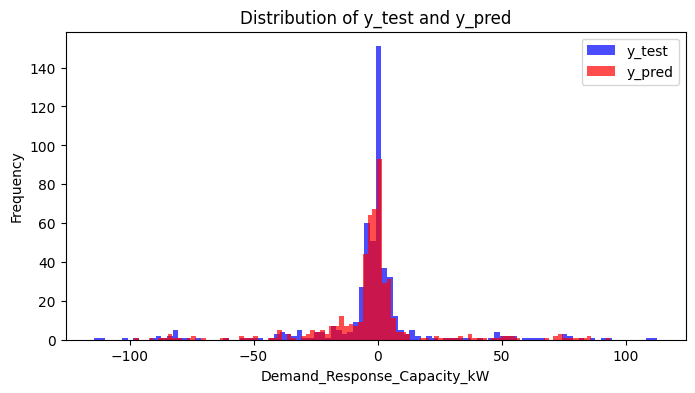

In [8]:
plt.figure(figsize=(8,4))
plt.hist(y_test, bins=100, alpha=0.7, label='y_test', color='blue')
plt.hist(y_pred, bins=100, alpha=0.7, label='y_pred', color='red')
plt.legend()
plt.xlabel('Demand_Response_Capacity_kW')
plt.ylabel('Frequency')
plt.title('Distribution of y_test and y_pred')
plt.show()

In [9]:
# print some statistics on y_test and y_pred
print(y_test.min(), y_test.max(), y_test.mean(), y_test.std())
print(y_pred.min(), y_pred.max(), y_pred.mean(), y_pred.std())

-114.38 112.84 -2.1169000000000007 25.74380639668501
-98.08708 93.881714 -2.3360791 23.703083


In [10]:
df_out = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred
})
df_out.head(10)

,y_test,y_pred
0,-5.67,-2.550298
1,1.80,1.597309
2,0.21,-0.476411
3,0.00,-0.242932
4,42.26,32.883068
5,-7.58,-2.783005
6,-3.55,-4.163684
7,-85.86,-23.709251
8,3.57,4.653211
9,-1.68,-2.004102


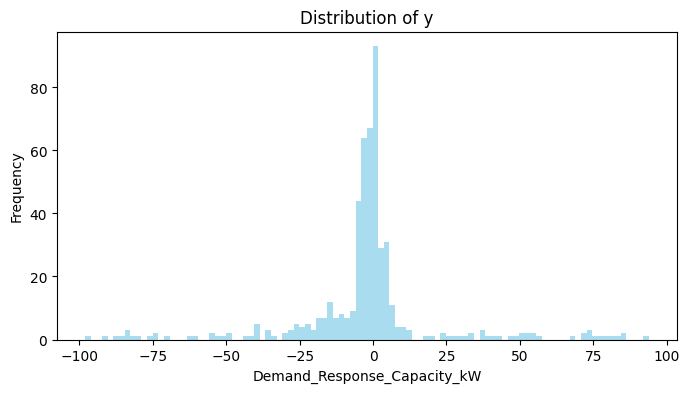

In [11]:
plt.figure(figsize=(8,4))
plt.hist(y_pred, bins=100, alpha=0.7, color='skyblue')
plt.xlabel('Demand_Response_Capacity_kW')
plt.ylabel('Frequency')
plt.title('Distribution of y')
plt.show()

In [12]:
# Save models
joblib.dump(clf_nz, './models/phase2_xgb_clf_nz_model.pkl')
joblib.dump(reg_nz, './models/phase2_xgb_reg_nz_model.pkl')
print("Models saved.")

Models saved.
